In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.cluster import KMeans

%matplotlib inline

## Loading the training data

Two training sets: one with repeated gestures (same gesture done multiple times in one recording) and one with single gestures.

In [2]:
# paths
repeated_dir = 'data/Repeated_gesture'
single_dir = 'data/Single_gesture'

# figure out which files belong to which gesture
# the naming is kinda inconsistent lol
gesture_prefixes = {
    'wave': 'wave',
    'inf': 'inf',       # infinity
    'eight': 'eight',
    'circle': 'circle',
    'beat3': 'beat3',
    'beat4': 'beat4'
}

def load_imu(fpath):
    raw = np.loadtxt(fpath)
    # columns: ts, Wx, Wy, Wz, Ax, Ay, Az
    # drop timestamp, keep 6D IMU
    return raw[:, 1:]

# load repeated gesture files
repeated_data = {}
for gname, prefix in gesture_prefixes.items():
    files = sorted(glob.glob(os.path.join(repeated_dir, prefix + '*.txt')))
    repeated_data[gname] = [load_imu(f) for f in files]
    print(f"{gname}: {len(files)} files, shapes: {[d.shape for d in repeated_data[gname]]}")

print()

# load single gesture files  
single_data = {}
for gname, prefix in gesture_prefixes.items():
    files = sorted(glob.glob(os.path.join(single_dir, prefix + '*.txt')))
    single_data[gname] = [load_imu(f) for f in files]
    print(f"{gname}: {len(files)} files, shapes: {[d.shape for d in single_data[gname]]}")

wave: 5 files, shapes: [(2266, 6), (2526, 6), (3225, 6), (3070, 6), (3443, 6)]
inf: 5 files, shapes: [(1983, 6), (3379, 6), (2495, 6), (2125, 6), (2435, 6)]
eight: 5 files, shapes: [(2391, 6), (3148, 6), (3371, 6), (2633, 6), (2758, 6)]
circle: 5 files, shapes: [(1944, 6), (2354, 6), (2133, 6), (2295, 6), (1901, 6)]
beat3: 5 files, shapes: [(2220, 6), (2608, 6), (2643, 6), (2865, 6), (3095, 6)]
beat4: 5 files, shapes: [(3017, 6), (3088, 6), (2307, 6), (2613, 6), (3009, 6)]

wave: 1 files, shapes: [(441, 6)]
inf: 1 files, shapes: [(852, 6)]
eight: 1 files, shapes: [(596, 6)]
circle: 1 files, shapes: [(628, 6)]
beat3: 1 files, shapes: [(749, 6)]
beat4: 1 files, shapes: [(845, 6)]


## Visualize the data

I want to see the raw IMU signals for each gesture to understand the patterns. Plotting one repeated file per gesture.

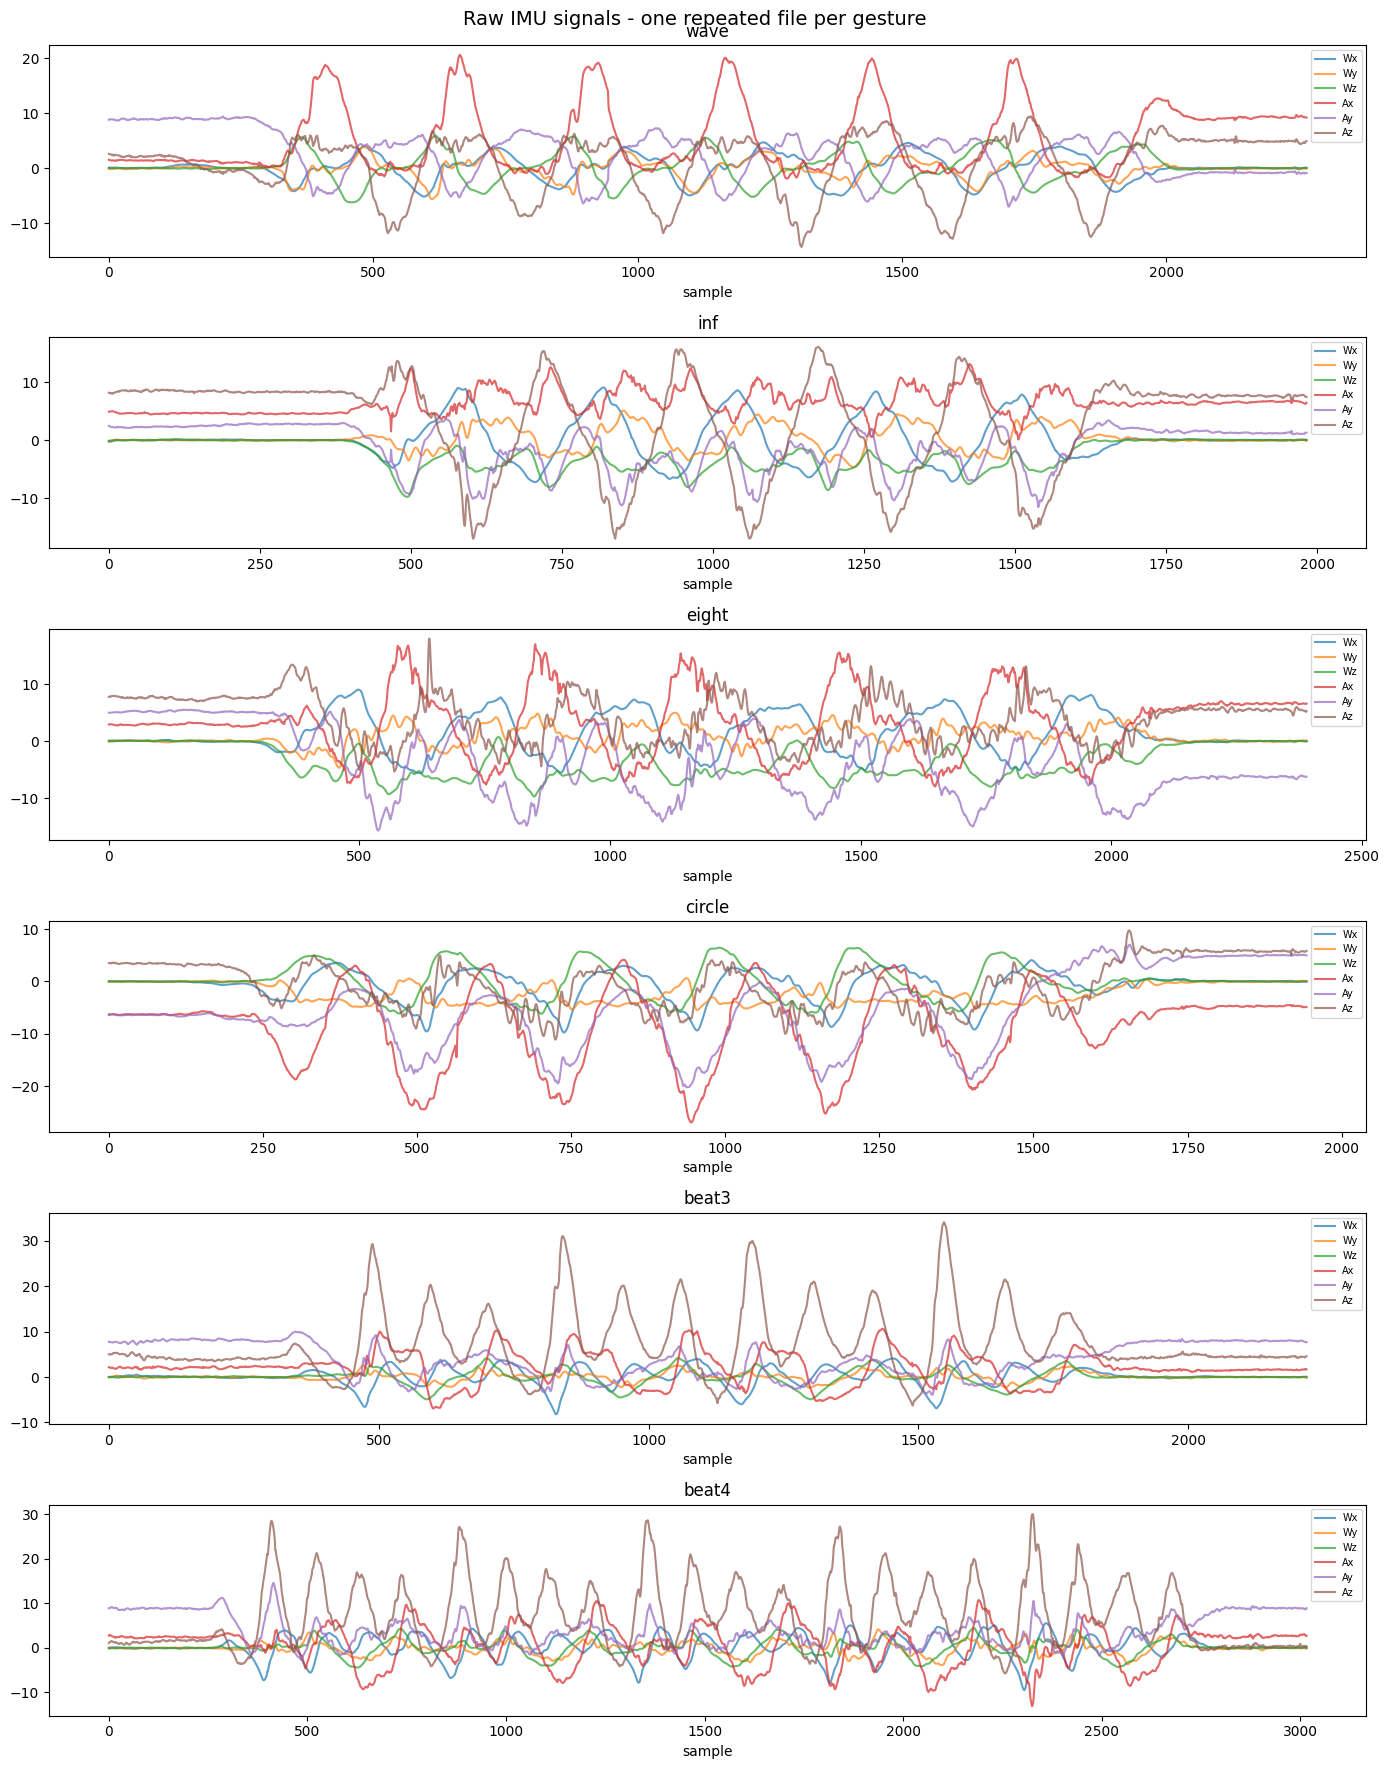

In [3]:
channel_names = ['Wx', 'Wy', 'Wz', 'Ax', 'Ay', 'Az']

fig, axes = plt.subplots(6, 1, figsize=(14, 18))
fig.suptitle('Raw IMU signals - one repeated file per gesture', fontsize=14)

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

for idx, (gname, dlist) in enumerate(repeated_data.items()):
    ax = axes[idx]
    dat = dlist[0]  # just look at the first file
    for ch in range(6):
        ax.plot(dat[:, ch], alpha=0.7, label=channel_names[ch])
    ax.set_title(gname)
    ax.legend(loc='upper right', fontsize=7)
    ax.set_xlabel('sample')

plt.tight_layout()
plt.show()

## Splitting repeated gestures into individual ones

The repeated gesture files contain the same gesture done multiple times. I wanted to split them into individual gestures. So I looked at the signal energy to find the "rest" periods between repetitions.

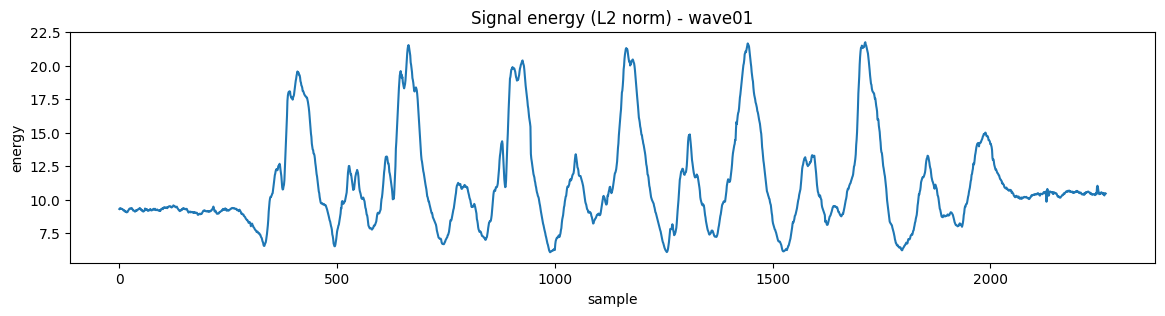

energy stats: min=6.085, max=21.741, mean=11.156


In [4]:
# first let me look at what the energy looks like for a wave file
test_dat = repeated_data['wave'][0]
energy = np.sqrt(np.sum(test_dat**2, axis=1))

plt.figure(figsize=(14, 3))
plt.plot(energy)
plt.title('Signal energy (L2 norm) - wave01')
plt.xlabel('sample')
plt.ylabel('energy')
plt.show()
print("energy stats: min={:.3f}, max={:.3f}, mean={:.3f}".format(energy.min(), energy.max(), energy.mean()))

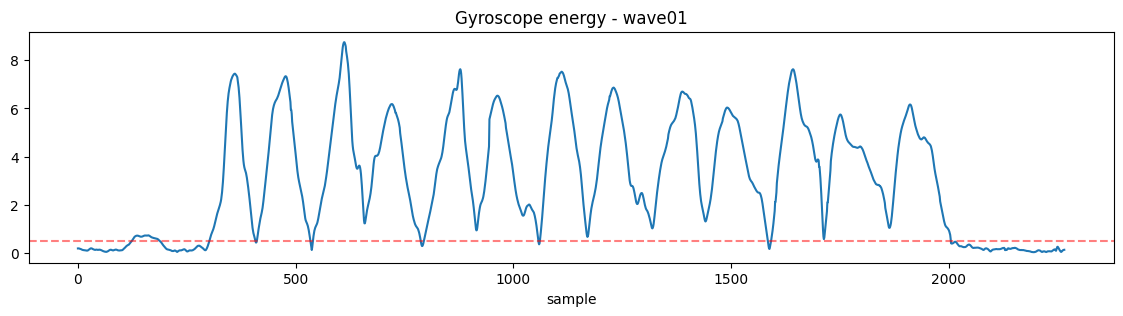

gyro energy stats: 0.023961734390481836 8.754146785229615 3.0421260046705427


In [5]:
# ok so the energy doesn't really go to zero between repetitions
# because of gravity component in accelerometer (always ~9.8)
# let me try looking at just the gyroscope channels which should be near zero when not moving

gyro_energy = np.sqrt(np.sum(test_dat[:, :3]**2, axis=1))

plt.figure(figsize=(14, 3))
plt.plot(gyro_energy)
plt.title('Gyroscope energy - wave01')
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.xlabel('sample')
plt.show()
print("gyro energy stats:", gyro_energy.min(), gyro_energy.max(), gyro_energy.mean())

In [6]:
def segment_gesture(imu_data, threshold=0.3, min_gesture_len=50, min_gap=30):
    """
    split a repeated gesture recording into individual gestures
    using gyroscope energy to find rest periods
    """
    gyro = imu_data[:, :3]
    energy = np.sqrt(np.sum(gyro**2, axis=1))
    
    # smooth it a bit
    kernel_size = 15
    kernel = np.ones(kernel_size) / kernel_size
    smooth_energy = np.convolve(energy, kernel, mode='same')
    
    # find active regions (above threshold)
    active = smooth_energy > threshold
    
    # find transitions
    segments = []
    in_gesture = False
    start = 0
    
    for i in range(len(active)):
        if active[i] and not in_gesture:
            start = i
            in_gesture = True
        elif not active[i] and in_gesture:
            if i - start >= min_gesture_len:
                segments.append((start, i))
            in_gesture = False
    
    # don't forget the last one if it ends while active
    if in_gesture and len(active) - start >= min_gesture_len:
        segments.append((start, len(active)))
    
    # merge segments that are too close together
    merged = []
    for seg in segments:
        if merged and seg[0] - merged[-1][1] < min_gap:
            merged[-1] = (merged[-1][0], seg[1])
        else:
            merged.append(seg)
    
    return [imu_data[s:e] for s, e in merged], merged

# test on wave01
segs, boundaries = segment_gesture(test_dat)
print(f"found {len(segs)} segments")
print("segment lengths:", [len(s) for s in segs])
print("boundaries:", boundaries)

found 2 segments
segment lengths: [83, 1727]
boundaries: [(114, 197), (298, 2025)]


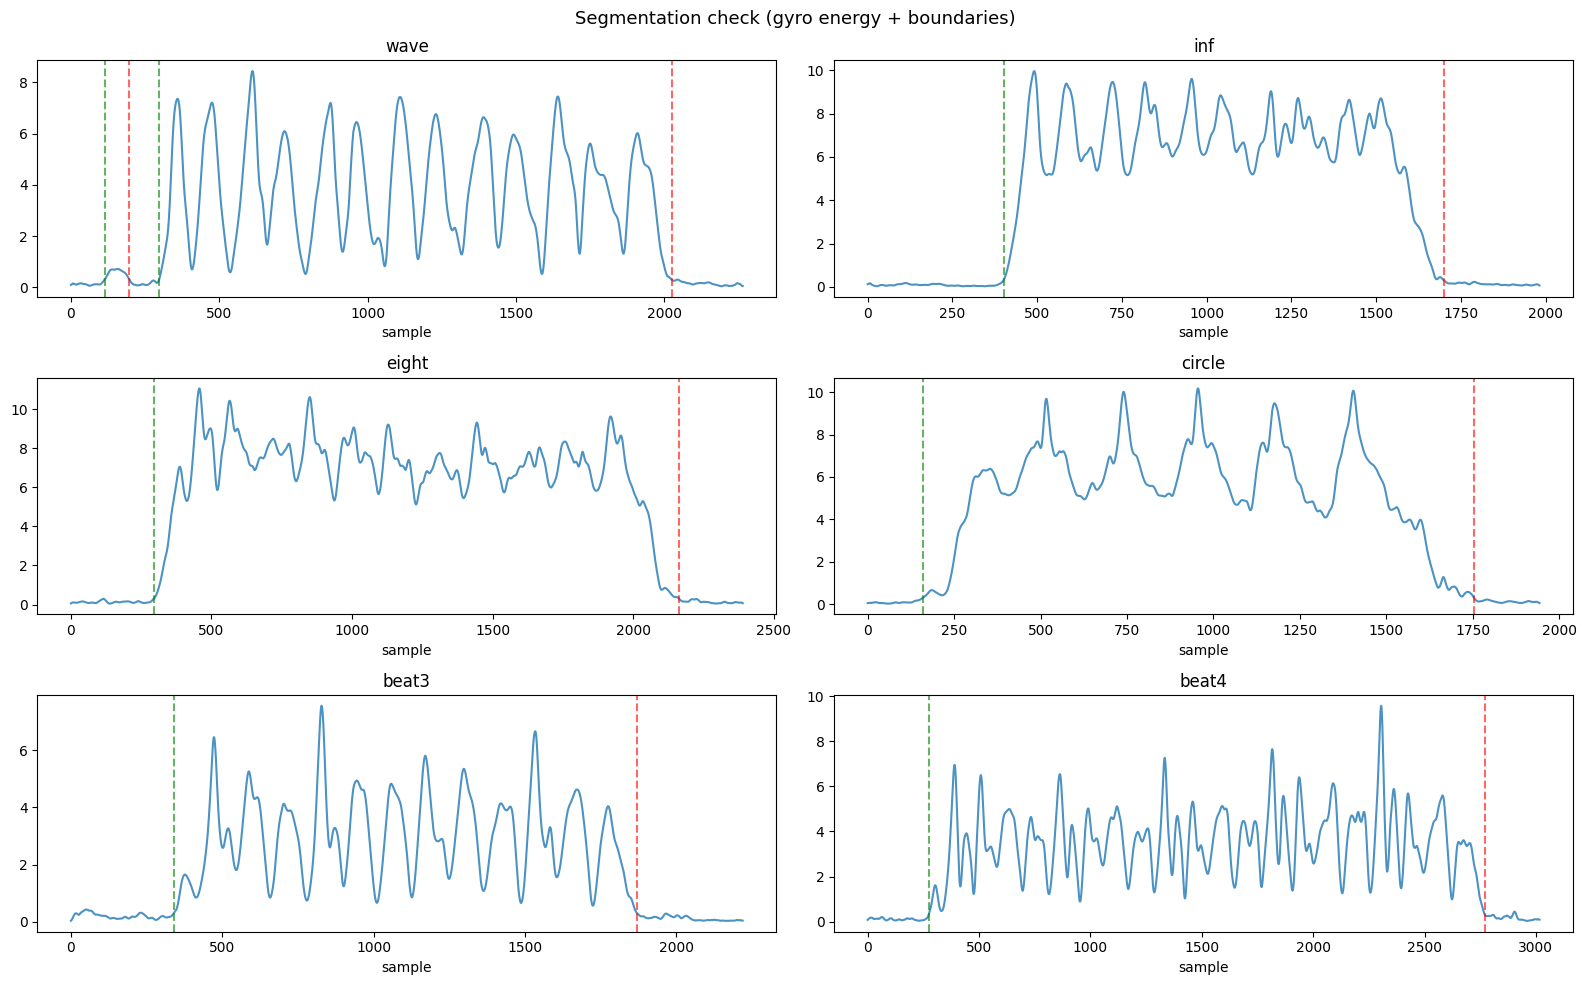

In [7]:
# visualize the segmentation for a few gestures
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle('Segmentation check (gyro energy + boundaries)', fontsize=13)

for idx, gname in enumerate(gesture_prefixes.keys()):
    ax = axes[idx // 2][idx % 2]
    dat = repeated_data[gname][0]
    gyro_e = np.sqrt(np.sum(dat[:, :3]**2, axis=1))
    
    # smooth for display
    k = np.ones(15) / 15
    smooth = np.convolve(gyro_e, k, mode='same')
    
    ax.plot(smooth, alpha=0.8)
    ax.set_title(gname)
    
    _, bounds = segment_gesture(dat)
    for s, e in bounds:
        ax.axvline(x=s, color='g', linestyle='--', alpha=0.6)
        ax.axvline(x=e, color='r', linestyle='--', alpha=0.6)
    
    ax.set_xlabel('sample')

plt.tight_layout()
plt.show()

Hmm so the segmentation basically gives one big chunk per file...the gestures are done continuously without clear rest periods between reps, the repeated files have maybe 3-6 reps but my method can't split them.

In [8]:
# hmm so the segmentation basically gives one big chunk per file...
# the gestures are done continuously without clear rest periods between reps
# each "segment" is like 1500-3000 samples but a single gesture is ~400-800 samples
# so the repeated files have maybe 3-6 reps but my method can't split them

# apply to all files to confirm
for gname in gesture_prefixes.keys():
    total_segs = 0
    for dat in repeated_data[gname]:
        segs, _ = segment_gesture(dat)
        total_segs += len(segs)
    avg_single_len = np.mean([len(s) for s in single_data[gname]])
    print(f"{gname}: {total_segs} segments from 5 files (expected ~{5 * repeated_data[gname][0].shape[0] / avg_single_len:.0f}+ individual gestures)")

wave: 6 segments from 5 files (expected ~26+ individual gestures)
inf: 5 segments from 5 files (expected ~12+ individual gestures)
eight: 6 segments from 5 files (expected ~20+ individual gestures)
circle: 6 segments from 5 files (expected ~15+ individual gestures)
beat3: 5 segments from 5 files (expected ~15+ individual gestures)
beat4: 5 segments from 5 files (expected ~18+ individual gestures)


## No split, use cyclic LR-HMM

Splitting the repeated gestures is not really working - the person just keeps moving without pausing between reps.

The HMM will need a cyclic left-to-right structure (last state can transition back to first state).

So my training data will be:
- Repeated gesture files: each file = 1 long sequence with the ~3-6 times repeated gesture
- Single gesture files: each file = 1 short sequence with one gesture

All 6 files per gesture go into training. I'll use leave-one-out CV later to check generalization.

In [9]:
# just use each file as one training sequence - no splitting
training_raw = {}
for gname in gesture_prefixes.keys():
    training_raw[gname] = repeated_data[gname] + single_data[gname]
    lens = [len(s) for s in training_raw[gname]]
    print(f"{gname}: {len(training_raw[gname])} sequences, lengths: {lens}")

wave: 6 sequences, lengths: [2266, 2526, 3225, 3070, 3443, 441]
inf: 6 sequences, lengths: [1983, 3379, 2495, 2125, 2435, 852]
eight: 6 sequences, lengths: [2391, 3148, 3371, 2633, 2758, 596]
circle: 6 sequences, lengths: [1944, 2354, 2133, 2295, 1901, 628]
beat3: 6 sequences, lengths: [2220, 2608, 2643, 2865, 3095, 749]
beat4: 6 sequences, lengths: [3017, 3088, 2307, 2613, 3009, 845]


## Vector Quantization with K-means

I need to discretize the continuous 6D IMU vectors into discrete observation labels for the HMM. Using k-means clustering.

But first I noticed the raw accel channels have way higher variance than gyro because of the gravity component (~9.8 m/s²). If I run kmeans directly the clusters would be dominated by accelerometer values. So I normalize first: subtract per-sequence mean (removes gravity bias) then divide by global std (equalizes channel contributions).

After that, k-means with M=70. I tried 70 first and it looked fine, later did a small grid search over [65, 70, 75] to confirm.

In [10]:
# ---- Feature Normalization ----
# Problem: raw accelerometer values include gravity (~9.8 m/s²) which dominates
# KMeans clustering (85% of variance from accel vs 15% from gyro).
# Different device orientations shift gravity across axes, making raw features
# orientation-dependent and causing poor generalization to new test data.
#
# Fix: per-sequence mean removal + global std normalization
#   1. Subtract per-sequence mean: removes static gravity bias
#   2. Divide by global std: equalizes gyro & accel channel contributions

def normalize_sequence(seq, global_std):
    """Per-sequence mean removal + global std normalization"""
    centered = seq - seq.mean(axis=0)
    return centered / global_std

# Compute global std from mean-centered training data
all_centered = []
for gname, seq_list in training_raw.items():
    for seq in seq_list:
        all_centered.append(seq - seq.mean(axis=0))

all_centered_stacked = np.vstack(all_centered)
global_std = all_centered_stacked.std(axis=0)
global_std[global_std < 1e-8] = 1.0

print("Global std per channel (after mean removal):")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: std={global_std[i]:.4f}")

# Normalize all training sequences
training_normalized = {}
for gname, seq_list in training_raw.items():
    training_normalized[gname] = [normalize_sequence(s, global_std) for s in seq_list]

# Verify: channel variance contributions should be ~equal now
all_norm = np.vstack([s for seqs in training_normalized.values() for s in seqs])
print(f"\ntotal normalized vectors: {all_norm.shape}")
total_var = all_norm.var(axis=0).sum()
gyro_pct = all_norm[:, :3].var(axis=0).sum() / total_var * 100
accel_pct = all_norm[:, 3:].var(axis=0).sum() / total_var * 100
print(f"Variance contribution: Gyro={gyro_pct:.1f}%, Accel={accel_pct:.1f}% (was 14.9% vs 85.1%)")
print("value ranges per channel:")
for i, ch in enumerate(channel_names):
    print(f"  {ch}: [{all_norm[:, i].min():.3f}, {all_norm[:, i].max():.3f}]")

Global std per channel (after mean removal):
  Wx: std=3.1036
  Wy: std=1.6168
  Wz: std=2.4367
  Ax: std=4.9737
  Ay: std=5.0927
  Az: std=6.1542

total normalized vectors: (83451, 6)
Variance contribution: Gyro=50.0%, Accel=50.0% (was 14.9% vs 85.1%)
value ranges per channel:
  Wx: [-3.232, 3.604]
  Wy: [-5.114, 4.108]
  Wz: [-2.988, 2.889]
  Ax: [-3.693, 3.395]
  Ay: [-3.933, 3.298]
  Az: [-3.295, 4.627]


fitting kmeans with 70 clusters on normalized data...


done! inertia: 60738.63002518326
cluster sizes: min=344, max=7608, mean=1192.2
empty clusters: 0


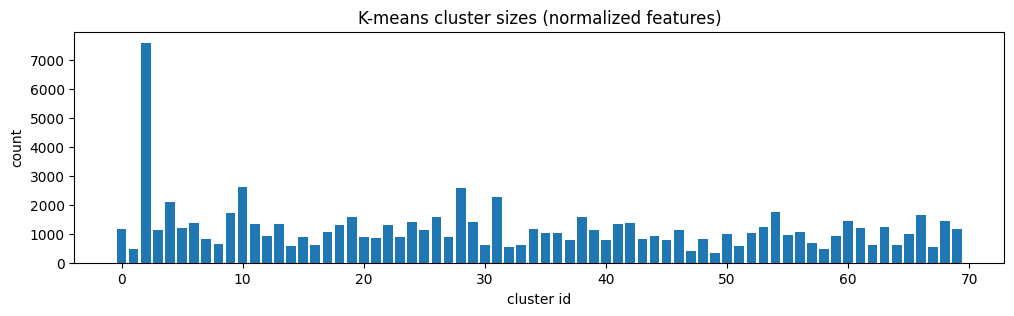

In [11]:
M = 70  # number of observation clusters
print(f"fitting kmeans with {M} clusters on normalized data...")
kmeans = KMeans(n_clusters=M, random_state=42, n_init=10, max_iter=300)
kmeans.fit(all_norm)
print("done! inertia:", kmeans.inertia_)

# check cluster sizes - don't want empty clusters
labels_all = kmeans.labels_
cluster_sizes = np.bincount(labels_all, minlength=M)
print(f"cluster sizes: min={cluster_sizes.min()}, max={cluster_sizes.max()}, mean={cluster_sizes.mean():.1f}")
print(f"empty clusters: {np.sum(cluster_sizes == 0)}")

plt.figure(figsize=(12, 3))
plt.bar(range(M), cluster_sizes)
plt.title('K-means cluster sizes (normalized features)')
plt.xlabel('cluster id')
plt.ylabel('count')
plt.show()

In [12]:
# quantize all normalized training sequences
def quantize(seq, km):
    return km.predict(seq)

training_obs = {}  # gesture -> list of 1D int arrays
for gname, seq_list in training_normalized.items():
    training_obs[gname] = [quantize(s, kmeans) for s in seq_list]
    print(f"{gname}: {len(training_obs[gname])} sequences")
    # sanity check
    print(f"  first seq labels: {training_obs[gname][0][:15]}")
    print(f"  seq lengths: {[len(s) for s in training_obs[gname]]}")

wave: 6 sequences
  first seq labels: [13 13 13 13 13 13 13 13 13 13 13 13 13 13 13]
  seq lengths: [2266, 2526, 3225, 3070, 3443, 441]
inf: 6 sequences
  first seq labels: [28 28 28 28 28 28 28 28 28 28 28 28 28 28 28]
  seq lengths: [1983, 3379, 2495, 2125, 2435, 852]
eight: 6 sequences
  first seq labels: [4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]
  seq lengths: [2391, 3148, 3371, 2633, 2758, 596]
circle: 6 sequences
  first seq labels: [69 69 69 69 69 69 69 69 69 69 69 69 69 69 69]
  seq lengths: [1944, 2354, 2133, 2295, 1901, 628]
beat3: 6 sequences
  first seq labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
  seq lengths: [2220, 2608, 2643, 2865, 3095, 749]
beat4: 6 sequences
  first seq labels: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
  seq lengths: [3017, 3088, 2307, 2613, 3009, 845]


In [13]:
import pickle

os.makedirs('models', exist_ok=True)

# save normalization parameters (needed at inference time)
norm_params = {'global_std': global_std}
with open('models/norm_params.pkl', 'wb') as f:
    pickle.dump(norm_params, f)
print("saved normalization parameters")

# save kmeans model
with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("saved kmeans model")

# save quantized training data
with open('models/training_obs.pkl', 'wb') as f:
    pickle.dump(training_obs, f)
print("saved training observations")

# also save the raw training sequences in case I need them later
with open('models/training_raw.pkl', 'wb') as f:
    pickle.dump(training_raw, f)
print("saved raw training data")

print(f"\nM = {M} clusters, total {sum(len(v) for v in training_obs.values())} training sequences")

saved normalization parameters
saved kmeans model
saved training observations
saved raw training data

M = 70 clusters, total 36 training sequences


## HMM Implementation

Time to build the actual HMM. Following Rabiner's paper mostly - the forward/backward algorithms and Baum-Welch for training. I'll use scaling to avoid numerical underflow (section V of the paper).

The plan is:
1. Build an HMM class with forward, backward, and training
2. Test it on some toy data first to make sure it works
3. Then train on the real gesture data

In [14]:
class HMM:
    def __init__(self, n_states, n_obs, topology='left-right-cyclic'):
        self.N = n_states
        self.M = n_obs
        self.topology = topology
        
        if topology == 'ergodic':
            self.pi = np.ones(self.N) / self.N
            self.A = np.random.dirichlet(np.ones(self.N), size=self.N)
        else:
            # left-right cyclic: start in state 0, can go forward or loop back
            self.pi = np.zeros(self.N)
            self.pi[0] = 1.0
            self.A = np.zeros((self.N, self.N))
            for i in range(self.N):
                stay = 0.5 + np.random.uniform(0, 0.2)
                self.A[i, i] = stay
                nxt = (i + 1) % self.N  # cyclic: last state -> first state
                self.A[i, nxt] = 1.0 - stay
        
        # B: random emission probs
        self.B = np.random.dirichlet(np.ones(self.M), size=self.N)
        self.B += 1e-8
        self.B /= self.B.sum(axis=1, keepdims=True)
        
        # mask for A structure - enforce during training
        self.A_mask = (self.A > 0).astype(float)
    
    def forward(self, obs):
        # scaled forward (rabiner section V)
        T = len(obs)
        alpha = np.zeros((self.N, T))
        c = np.zeros(T)
        
        alpha[:, 0] = self.pi * self.B[:, obs[0]]
        c[0] = alpha[:, 0].sum() + 1e-300
        alpha[:, 0] /= c[0]
        
        for t in range(1, T):
            alpha[:, t] = (self.A.T @ alpha[:, t-1]) * self.B[:, obs[t]]
            c[t] = alpha[:, t].sum() + 1e-300
            alpha[:, t] /= c[t]
        return alpha, c
    
    def backward(self, obs, c):
        T = len(obs)
        beta = np.zeros((self.N, T))
        beta[:, T-1] = 1.0 / c[T-1]
        for t in range(T-2, -1, -1):
            beta[:, t] = self.A @ (self.B[:, obs[t+1]] * beta[:, t+1])
            beta[:, t] /= c[t]
        return beta
    
    def log_likelihood(self, obs):
        _, c = self.forward(obs)
        return np.sum(np.log(c))
    
    def train(self, obs_sequences, max_iter=100, tol=1e-4, verbose=True):
        ll_history = []
        
        for epoch in range(max_iter):
            total_ll = 0
            # accumulate stats directly instead of storing all gamma/xi
            # (the old way kept all xi arrays in memory and blew up on long runs)
            xi_sum = np.zeros((self.N, self.N))
            gamma_denom_A = np.zeros(self.N)
            gamma_denom_B = np.zeros(self.N)
            B_numer = np.zeros((self.N, self.M))
            
            for obs in obs_sequences:
                alpha, c = self.forward(obs)
                beta = self.backward(obs, c)
                T = len(obs)
                
                gamma = alpha * beta
                gamma /= gamma.sum(axis=0, keepdims=True) + 1e-300
                
                # accumulate stats for B
                gamma_denom_B += gamma.sum(axis=1)
                for t in range(T):
                    B_numer[:, obs[t]] += gamma[:, t]
                
                # accumulate stats for A
                gamma_denom_A += gamma[:, :-1].sum(axis=1)
                for t in range(T-1):
                    bj_beta = self.B[:, obs[t+1]] * beta[:, t+1]
                    xi_t = alpha[:, t:t+1] * self.A * bj_beta[np.newaxis, :]
                    xi_t /= xi_t.sum() + 1e-300
                    xi_sum += xi_t
                
                total_ll += np.sum(np.log(c))
            
            ll_history.append(total_ll)
            
            if epoch > 0:
                ll_change = total_ll - ll_history[-2]
                if verbose and epoch % 5 == 0:
                    print(f"  epoch {epoch}: LL = {total_ll:.2f} (change: {ll_change:.4f})")
                if ll_change < -0.01:
                    print(f"  WARNING: LL decreased at epoch {epoch}!")
                if abs(ll_change) < tol:
                    if verbose:
                        print(f"  converged at epoch {epoch}, LL = {total_ll:.2f}")
                    break
            elif verbose:
                print(f"  epoch 0: LL = {total_ll:.2f}")
            
            # M-step: update A
            gamma_denom_A[gamma_denom_A == 0] = 1e-300
            A_new = xi_sum / gamma_denom_A[:, np.newaxis]
            A_new *= self.A_mask  # enforce structure
            A_new /= A_new.sum(axis=1, keepdims=True) + 1e-300
            
            # M-step: update B
            gamma_denom_B[gamma_denom_B == 0] = 1e-300
            B_new = B_numer / gamma_denom_B[:, np.newaxis]
            B_new += 1e-8
            B_new /= B_new.sum(axis=1, keepdims=True)
            
            self.A = A_new
            self.B = B_new
        
        if verbose:
            print(f"  done: LL = {ll_history[-1]:.2f}, {len(ll_history)} epochs")
        return ll_history

print("HMM class ready")

HMM class ready


## Testing on toy data

I created a 2-state, 2-observation toy problem:
- State 0 always emits observation 0
- State 1 emits 0 or 1 with equal probability
- The sequence goes: 1000 zeros, then 1000 random {0,1}, then 1000 zeros

Using ergodic topology since the toy data goes state 0 → 1 → 0 (not left-to-right).

In [15]:
# generate toy data
np.random.seed(123)
seg1 = np.zeros(1000, dtype=int)           # state 0: always emits 0
seg2 = np.random.randint(0, 2, size=1000)  # state 1: emits 0 or 1 equally
seg3 = np.zeros(1000, dtype=int)           # state 0 again
toy_obs = np.concatenate([seg1, seg2, seg3])
print("toy obs:", toy_obs.shape, "unique:", np.unique(toy_obs))

# train on this
np.random.seed(4)  # tried a few seeds, this one converges nicely
toy_hmm = HMM(n_states=2, n_obs=2, topology='ergodic')
print("training...")
toy_ll = toy_hmm.train([toy_obs], max_iter=100, tol=1e-6)

toy obs: (3000,) unique: [0 1]
training...


  epoch 0: LL = -1396.16


  epoch 5: LL = -1362.74 (change: 5.0589)


  epoch 10: LL = -1249.90 (change: 51.0180)


  epoch 15: LL = -708.82 (change: 32.0050)


  converged at epoch 18, LL = -707.50
  done: LL = -707.50, 19 epochs


Learned A:
[[9.98996563e-01 1.00343720e-03]
 [5.02374098e-04 9.99497626e-01]]

Learned B:
[[4.80438924e-01 5.19561076e-01]
 [9.99999990e-01 1.04039591e-08]]

state 1 -> zeros emitter: B = [9.99999990e-01 1.04039591e-08] (expect ~[1, 0])
state 0 -> mixed emitter:  B = [0.48043892 0.51956108] (expect ~[0.5, 0.5])
A diag: [0.9995, 0.9990] (expect ~0.999)

LL monotonic: True


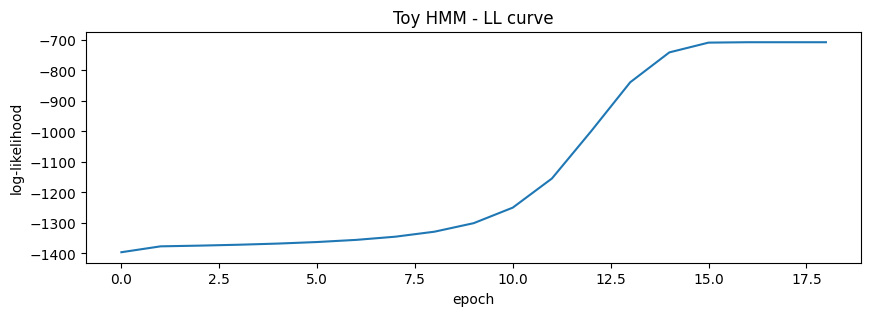

In [16]:
# check results
print("Learned A:")
print(toy_hmm.A)
print("\nLearned B:")
print(toy_hmm.B)

# figure out which state is which (labels can be swapped)
if toy_hmm.B[0, 1] < toy_hmm.B[1, 1]:
    s0, s1 = 0, 1
else:
    s0, s1 = 1, 0
print(f"\nstate {s0} -> zeros emitter: B = {toy_hmm.B[s0]} (expect ~[1, 0])")
print(f"state {s1} -> mixed emitter:  B = {toy_hmm.B[s1]} (expect ~[0.5, 0.5])")
print(f"A diag: [{toy_hmm.A[s0,s0]:.4f}, {toy_hmm.A[s1,s1]:.4f}] (expect ~0.999)")

# LL should be monotonically increasing
ll_diffs = np.diff(toy_ll)
print(f"\nLL monotonic: {np.all(ll_diffs >= -1e-6)}")

plt.figure(figsize=(10, 3))
plt.plot(toy_ll)
plt.title('Toy HMM - LL curve')
plt.xlabel('epoch'); plt.ylabel('log-likelihood')
plt.show()

## Training gesture HMMs

Now let me train one model per gesture. N=15 states, M=70 obs, left-right-cyclic.

After training I'll do leave-one-out cross-validation to check how well the models generalize.

In [17]:
N = 15  # hidden states
gesture_models = {}
gesture_ll_curves = {}

for gname in gesture_prefixes.keys():
    print(f"\n=== Training {gname} ===")
    np.random.seed(42)
    hmm = HMM(n_states=N, n_obs=M, topology='left-right-cyclic')
    ll = hmm.train(training_obs[gname], max_iter=200, tol=1e-2)
    gesture_models[gname] = hmm
    gesture_ll_curves[gname] = ll
    print(f"  A diag range: [{np.diag(hmm.A).min():.3f}, {np.diag(hmm.A).max():.3f}]")


=== Training wave ===


  epoch 0: LL = -55373.89


  epoch 5: LL = -12017.64 (change: 676.5746)


  epoch 10: LL = -10863.41 (change: 4.5669)


  epoch 15: LL = -10854.53 (change: 0.5428)


...

  epoch 110: LL = -14538.45 (change: 0.3955)


  epoch 115: LL = -14536.57 (change: 0.3045)


  epoch 120: LL = -14535.78 (change: 0.0827)


  epoch 125: LL = -14535.61 (change: 0.0162)


  converged at epoch 127, LL = -14535.59
  done: LL = -14535.59, 128 epochs
  A diag range: [0.000, 0.971]


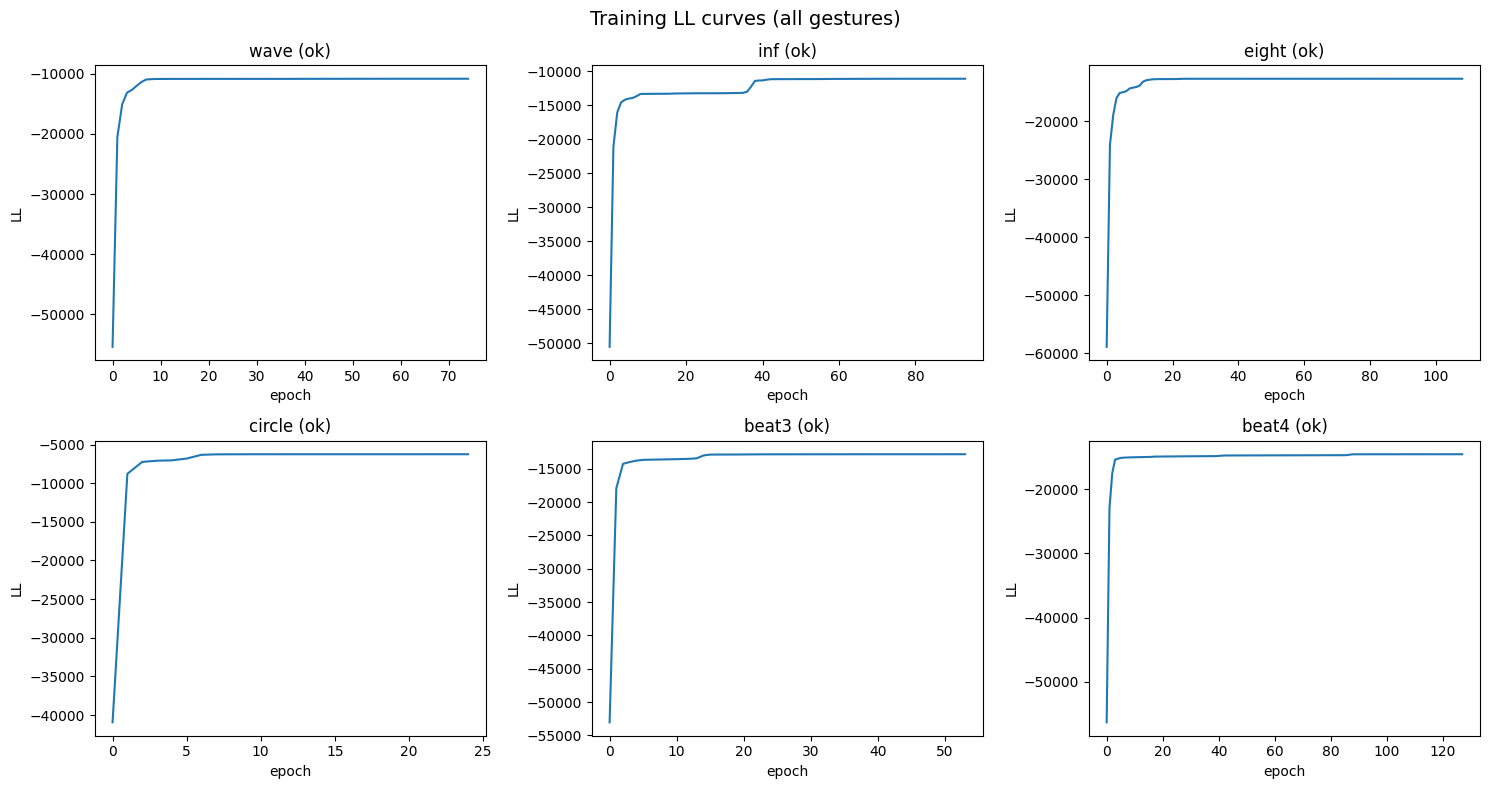

saved LL curves to docs/figures/


In [18]:
# plot LL curves for all gestures
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Training LL curves (all gestures)', fontsize=14)

for idx, gname in enumerate(gesture_prefixes.keys()):
    ax = axes[idx // 3][idx % 3]
    ax.plot(gesture_ll_curves[gname])
    ax.set_title(gname)
    ax.set_xlabel('epoch')
    ax.set_ylabel('LL')
    # check monotonicity
    diffs = np.diff(gesture_ll_curves[gname])
    is_mono = np.all(diffs >= -0.1)
    ax.set_title(f"{gname} ({'ok' if is_mono else 'BAD'})")

plt.tight_layout()
plt.savefig('docs/figures/ll_curves_all.png', dpi=100)
plt.show()
print("saved LL curves to docs/figures/")

In [19]:
# Leave-One-Out Cross-Validation
# for each gesture, hold out 1 of 6 sequences, train on remaining 5,
# classify the held-out one against all 6 models
print("=== Leave-One-Out Cross-Validation ===\n")

loocv_results = []  # (true_gesture, fold, pred, top3, correct)
correct = 0
total = 0

for true_gesture in gesture_prefixes.keys():
    seqs = training_obs[true_gesture]
    n_seqs = len(seqs)
    gcorrect = 0
    
    for fold in range(n_seqs):
        train_seqs = [seqs[i] for i in range(n_seqs) if i != fold]
        val_seq = seqs[fold]
        
        # retrain this gesture's model without the held-out seq
        np.random.seed(42)
        fold_hmm = HMM(n_states=N, n_obs=M, topology='left-right-cyclic')
        fold_hmm.train(train_seqs, max_iter=200, tol=1e-2, verbose=False)
        
        # classify against all models
        lls = {}
        for gname in gesture_prefixes.keys():
            if gname == true_gesture:
                lls[gname] = fold_hmm.log_likelihood(val_seq)
            else:
                lls[gname] = gesture_models[gname].log_likelihood(val_seq)
        
        ranked = sorted(lls.items(), key=lambda x: -x[1])
        pred = ranked[0][0]
        top3 = [r[0] for r in ranked[:3]]
        is_correct = pred == true_gesture
        correct += int(is_correct)
        gcorrect += int(is_correct)
        total += 1
        
        seq_type = "single" if fold == n_seqs - 1 else f"rep{fold+1}"
        mark = "ok" if is_correct else "WRONG"
        print(f"  {true_gesture} [{seq_type}]: pred={pred} [{mark}]  top3={top3}")
        loocv_results.append((true_gesture, fold, pred, top3, is_correct))
    
    print(f"  -> {true_gesture}: {gcorrect}/{n_seqs}\n")

t3_corr = sum(1 for tg, _, _, t3, _ in loocv_results if tg in t3)
print(f"Overall LOOCV: {correct}/{total} = {correct/total:.1%} Top-1, {t3_corr}/{total} = {t3_corr/total:.1%} Top-3")

=== Leave-One-Out Cross-Validation ===



  wave [rep1]: pred=wave [ok]  top3=['wave', 'eight', 'inf']


  wave [rep2]: pred=wave [ok]  top3=['wave', 'eight', 'inf']


  wave [rep3]: pred=wave [ok]  top3=['wave', 'eight', 'inf']


  wave [rep4]: pred=wave [ok]  top3=['wave', 'eight', 'inf']


...

  beat4 [rep2]: pred=beat4 [ok]  top3=['beat4', 'beat3', 'inf']


  beat4 [rep3]: pred=beat4 [ok]  top3=['beat4', 'beat3', 'inf']


  beat4 [rep4]: pred=beat4 [ok]  top3=['beat4', 'beat3', 'inf']


  beat4 [rep5]: pred=beat4 [ok]  top3=['beat4', 'beat3', 'inf']


  beat4 [single]: pred=beat4 [ok]  top3=['beat4', 'beat3', 'circle']
  -> beat4: 6/6

Overall LOOCV: 36/36 = 100.0% Top-1, 36/36 = 100.0% Top-3


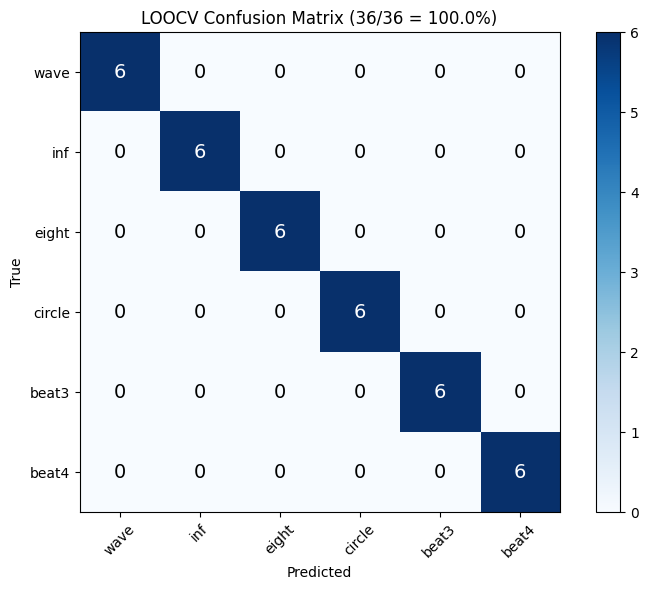

saved confusion matrix


In [20]:
# confusion matrix from LOOCV
gnames = list(gesture_prefixes.keys())
n_gestures = len(gnames)
conf = np.zeros((n_gestures, n_gestures), dtype=int)

for true_g, fold, pred_g, _, _ in loocv_results:
    i = gnames.index(true_g)
    j = gnames.index(pred_g)
    conf[i, j] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks(range(n_gestures))
ax.set_yticks(range(n_gestures))
ax.set_xticklabels(gnames, rotation=45)
ax.set_yticklabels(gnames)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'LOOCV Confusion Matrix ({correct}/{total} = {correct/total:.1%})')

# put numbers in cells
for i in range(n_gestures):
    for j in range(n_gestures):
        color = 'white' if conf[i, j] > 3 else 'black'
        ax.text(j, i, str(conf[i, j]), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.savefig('docs/figures/loocv_confusion.png', dpi=100)
plt.show()
print("saved confusion matrix")

In [21]:
# save trained models
for gname, model in gesture_models.items():
    model_data = {
        'A': model.A, 'B': model.B, 'pi': model.pi,
        'N': model.N, 'M': model.M,
        'topology': model.topology
    }
    fname = f'models/{gname}_hmm.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"saved {fname}")

print("all models saved")

saved models/wave_hmm.pkl
saved models/inf_hmm.pkl
saved models/eight_hmm.pkl
saved models/circle_hmm.pkl
saved models/beat3_hmm.pkl
saved models/beat4_hmm.pkl
all models saved
